## Import Library

In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG16, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_resnet
from tensorflow.keras.applications.vgg16 import preprocess_input as pre_vgg
from tensorflow.keras.applications.inception_v3 import preprocess_input as pre_inception
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay)
import joblib
from PIL import Image

## Config

In [17]:
CONFIG = {
    "DATASET_DIR" : "../dataset/dataset_cocoa_leaf/",
    "OUTPUT_DIR"  : "../clf/output_7030/",
    "CLASSES"     : ["sehat", "nitrogen_def", "fosfor_def", "kalium_def"],
    "TEST_SIZE"   : 0.3,
    "BATCH_SIZE"  : 16,
    "SEED"        : 42,
    "N_AUG"       : 5,
    "PARAM_GRID"  : [
        {"classifier__estimator__kernel": ["linear"],
         "classifier__estimator__C"     : [0.1, 1, 10, 100]},
        {"classifier__estimator__kernel": ["rbf"],
         "classifier__estimator__C"     : [0.1, 1, 10, 100],
         "classifier__estimator__gamma" : [0.001, 0.01, 0.1, 1]},
    ],
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

## Load Dataset

In [18]:
def load_img_padded(path, target_size, pad_color=(200, 200, 200)):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    max_side = max(w, h)
    canvas = Image.new("RGB", (max_side, max_side), pad_color)
    canvas.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
    return np.array(canvas.resize(target_size, Image.BILINEAR))

In [19]:
def load_dataset(dataset_dir, classes):
    X_224, X_299, y, file_names = [], [], [], []

    for label_idx, kelas in enumerate(classes):
        folder = os.path.join(dataset_dir, kelas)
        files  = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])
        for fname in files:
            fpath = os.path.join(folder, fname)
            X_224.append(load_img_padded(fpath, (224, 224)))
            X_299.append(load_img_padded(fpath, (299, 299)))
            y.append(label_idx)
            file_names.append(fname)
        print(f"{kelas}: {len(files)} citra")

    return np.array(X_224), np.array(X_299), np.array(y), file_names


X_224, X_299, y, file_names = load_dataset(CONFIG["DATASET_DIR"], CONFIG["CLASSES"])
print(f"\nTotal: {len(y)} citra")
print(f"Ukuran data X_224: {X_224.shape}")
print(f"Ukuran data X_299: {X_299.shape}")

sehat: 50 citra
nitrogen_def: 50 citra
fosfor_def: 50 citra
kalium_def: 50 citra

Total: 200 citra
Ukuran data X_224: (200, 224, 224, 3)
Ukuran data X_299: (200, 299, 299, 3)


## Split Dataset

In [20]:
idx = np.arange(len(y))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["SEED"], stratify=y
)

X224_train, X224_test = X_224[idx_train], X_224[idx_test]
X299_train, X299_test = X_299[idx_train], X_299[idx_test]

print(f"Train: {len(y_train)}")
print(f"Test : {len(y_test)}\n")
for i, k in enumerate(CONFIG["CLASSES"]):
    print(f"{k}: train={np.sum(y_train==i)}  test={np.sum(y_test==i)}")

Train: 140
Test : 60

sehat: train=35  test=15
nitrogen_def: train=35  test=15
fosfor_def: train=35  test=15
kalium_def: train=35  test=15


## Augmentasi Data

In [21]:
augmentor = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    vertical_flip=True,
    channel_shift_range=10.0,
    fill_mode='nearest'
)


def augment(X, y, n_aug=5, seed=42):
    rng = np.random.RandomState(seed)
    X_aug = [X] + [
        np.array([augmentor.random_transform(img, seed=rng.randint(0, 99999)) for img in X])
        for _ in range(n_aug)
    ]
    return np.concatenate(X_aug), np.concatenate([y] * (n_aug + 1))


X224_aug, y_aug = augment(X224_train, y_train, CONFIG["N_AUG"], CONFIG["SEED"])
X299_aug, _     = augment(X299_train, y_train, CONFIG["N_AUG"], CONFIG["SEED"])
print(f"Setelah augmentasi: {len(y_aug)} citra (x{CONFIG['N_AUG']+1} dari {len(y_train)})")

Setelah augmentasi: 840 citra (x6 dari 140)


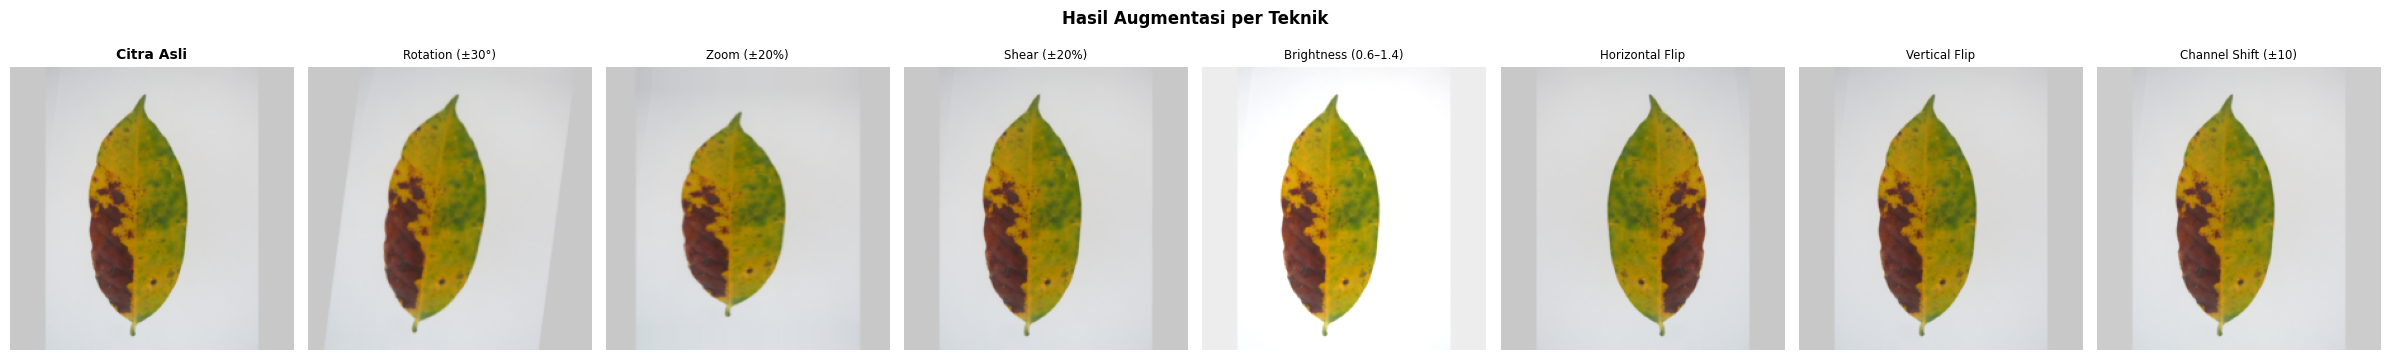

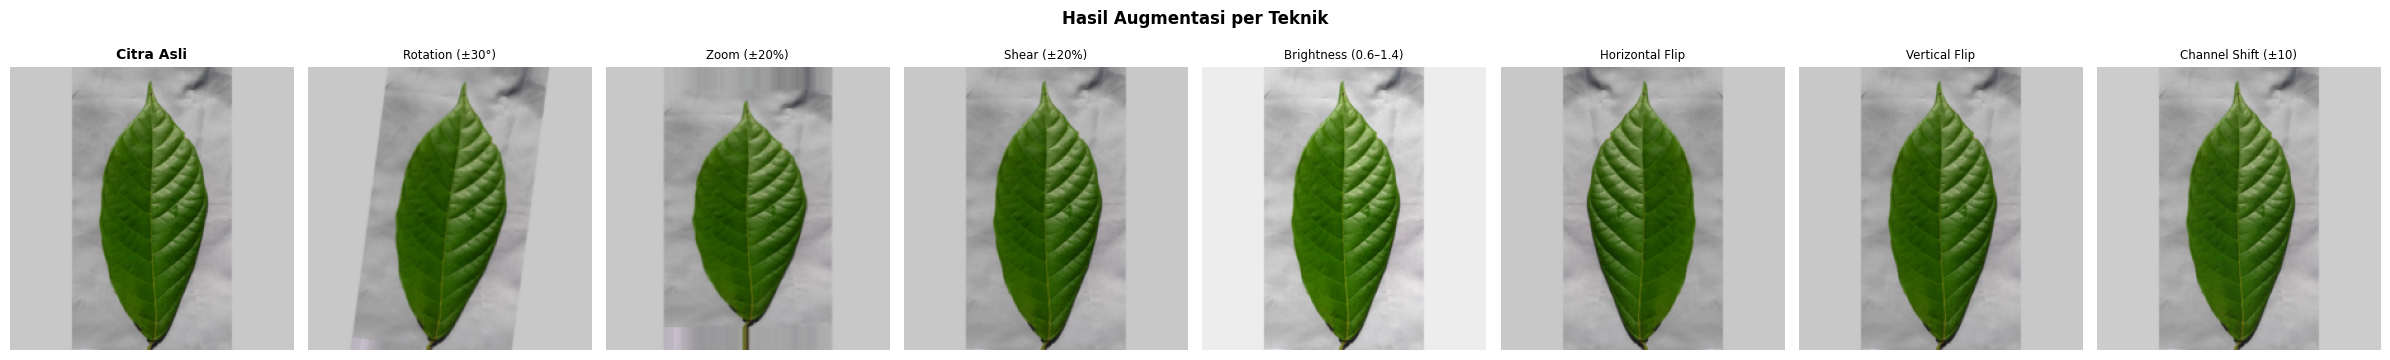

In [22]:
def visualize_per_technique(img_uint8, seed=42):
    TECHNIQUES = {
        "Rotation (±30°)": ImageDataGenerator(rotation_range=30, fill_mode="nearest"),
        "Zoom (±20%)": ImageDataGenerator(zoom_range=0.2, fill_mode="nearest"),
        "Shear (±20%)": ImageDataGenerator(shear_range=0.2, fill_mode="nearest"),
        "Brightness (0.6–1.4)": ImageDataGenerator(brightness_range=[0.6,1.4], fill_mode="nearest"),
        "Horizontal Flip": ImageDataGenerator(horizontal_flip=True, fill_mode="nearest"),
        "Vertical Flip": ImageDataGenerator(vertical_flip=True, fill_mode="nearest"),
        "Channel Shift (±10)": ImageDataGenerator(channel_shift_range=10.0, fill_mode="nearest"),
    }

    n_tech = len(TECHNIQUES)
    fig, axes = plt.subplots(1, n_tech + 1, figsize=(3 * (n_tech + 1), 3.5))

    axes[0].imshow(img_uint8)
    axes[0].set_title("Citra Asli", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    for ax, (name, gen) in zip(axes[1:], TECHNIQUES.items()):
        aug_img = gen.random_transform(img_uint8.astype(np.float32), seed=seed)
        ax.imshow(np.clip(aug_img, 0, 255).astype(np.uint8))
        ax.set_title(name, fontsize=8.5)
        ax.axis("off")

    plt.suptitle("Hasil Augmentasi per Teknik", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


sample_img_1 = X224_train[2]
sample_img_2 = X224_train[1]
visualize_per_technique(sample_img_1, seed=CONFIG["SEED"])
visualize_per_technique(sample_img_2, seed=CONFIG["SEED"])

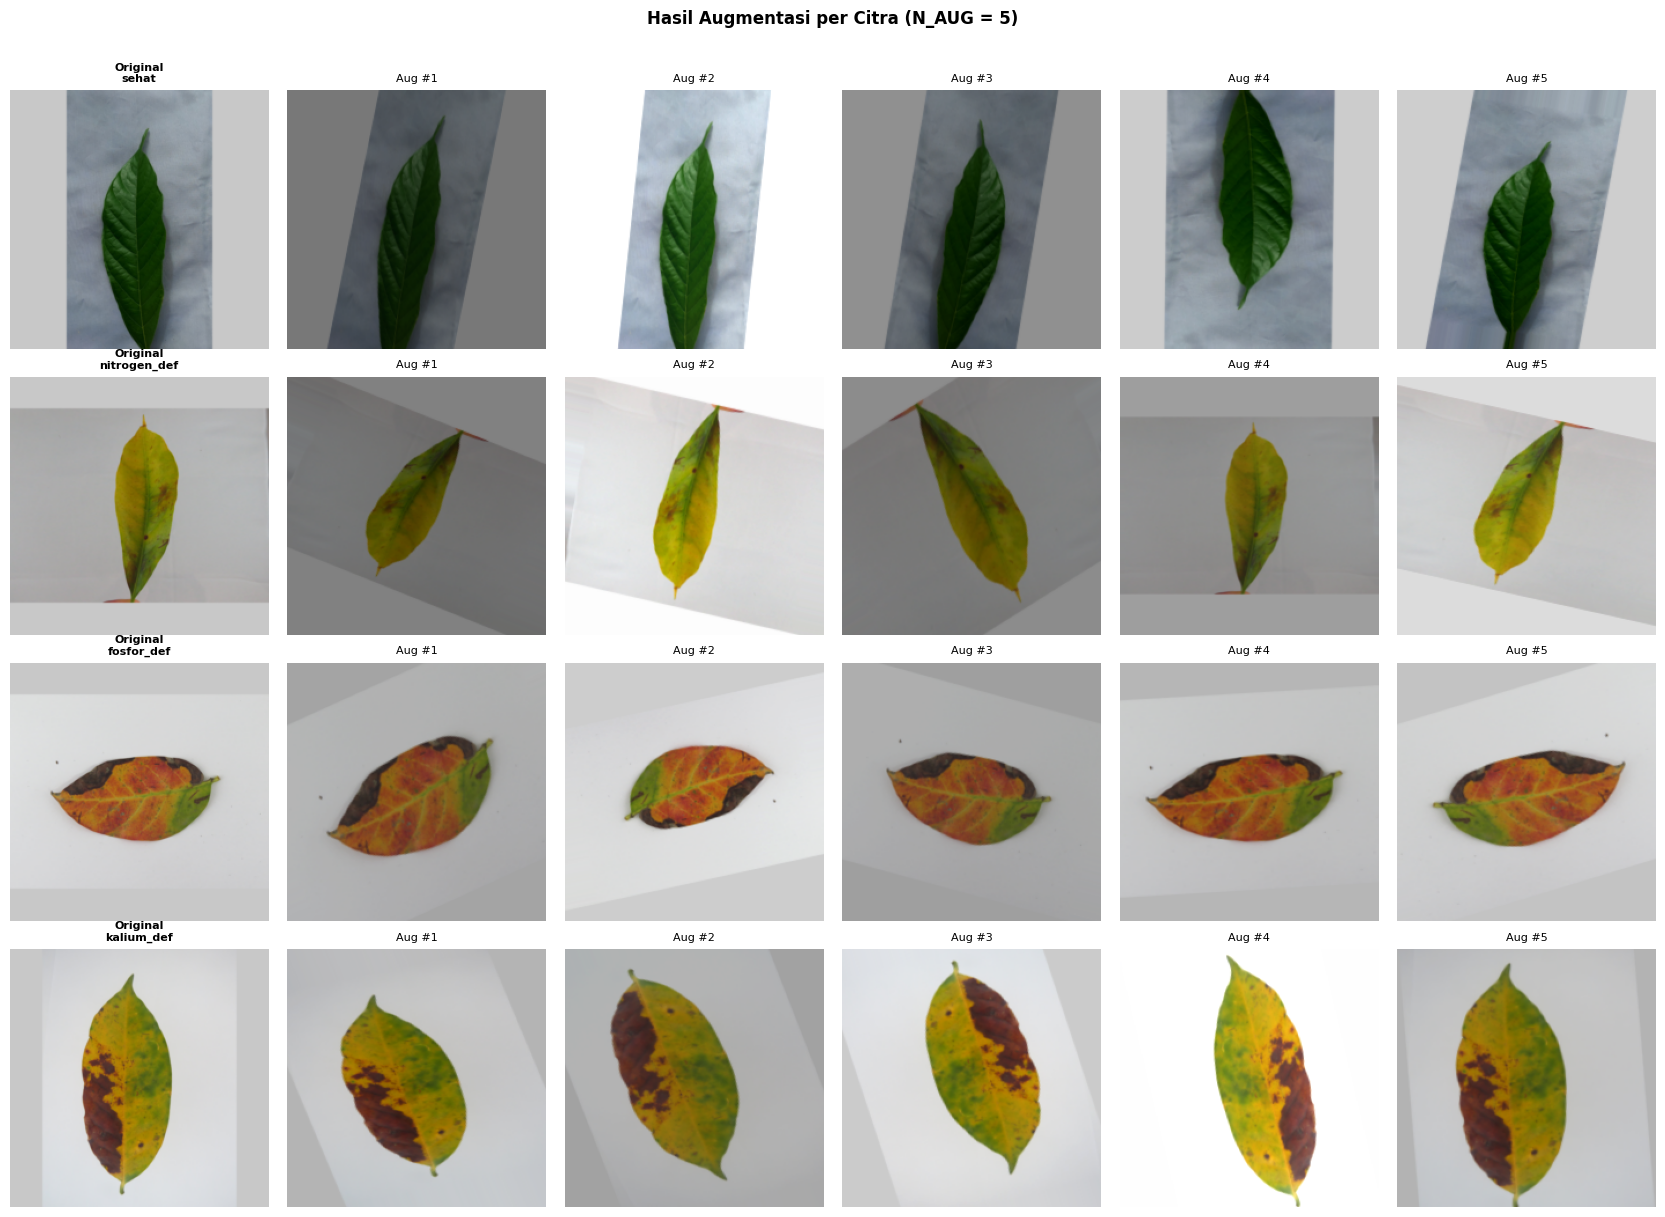

In [23]:
def visualize_n_aug(X, y, n_aug, classes, seed=42, sample_indices=None):
    rng = np.random.RandomState(seed)

    if sample_indices is None:
        sample_indices = []
        for cls_idx in range(len(classes)):
            idxs = np.where(y == cls_idx)[0]
            if len(idxs):
                sample_indices.append(idxs[0])

    n_rows = len(sample_indices)
    n_cols = n_aug + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 3.0 * n_rows), squeeze=False)

    for row, idx in enumerate(sample_indices):
        img  = X[idx]
        label = classes[y[idx]]

        axes[row][0].imshow(img)
        axes[row][0].set_title("Original\n" + label, fontsize=8, fontweight="bold")
        axes[row][0].axis("off")

        for aug_i in range(n_aug):
            aug_seed = rng.randint(0, 99999)
            aug_img  = augmentor.random_transform(img.astype(np.float32), seed=aug_seed)
            axes[row][aug_i + 1].imshow(np.clip(aug_img, 0, 255).astype(np.uint8))
            axes[row][aug_i + 1].set_title(f"Aug #{aug_i + 1}", fontsize=8)
            axes[row][aug_i + 1].axis("off")

    plt.suptitle(
        f"Hasil Augmentasi per Citra (N_AUG = {n_aug})",
        fontsize=12, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

visualize_n_aug(X224_train, y_train, n_aug=CONFIG["N_AUG"], classes=CONFIG["CLASSES"], seed=CONFIG["SEED"])

## Feature Extraction — 3 CNN

In [24]:
CNN_MODELS = [
    {"name": "ResNet50", "fn": ResNet50, "pre": pre_resnet, "size": 224, "X_train": None, "X_test": None},
    {"name": "VGG16", "fn": VGG16, "pre": pre_vgg, "size": 224, "X_train": None, "X_test": None},
    {"name": "InceptionV3", "fn": InceptionV3, "pre": pre_inception, "size": 299, "X_train": None, "X_test": None},
]

CNN_MODELS[0]["X_train"], CNN_MODELS[0]["X_test"] = X224_aug,  X224_test
CNN_MODELS[1]["X_train"], CNN_MODELS[1]["X_test"] = X224_aug,  X224_test
CNN_MODELS[2]["X_train"], CNN_MODELS[2]["X_test"] = X299_aug,  X299_test


def build_extractor(model_fn, img_size):
    base = model_fn(weights='imagenet', include_top=False,
                    input_shape=(img_size, img_size, 3))
    base.trainable = False
    out = GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=out)


def extract_features(extractor, pre_fn, X, batch_size=16):
    X_pre = np.array([pre_fn(img) for img in X])
    return extractor.predict(X_pre, batch_size=batch_size, verbose=0)

In [25]:
F_train_list, F_test_list = [], []

for cfg in CNN_MODELS:
    print(f"Ekstraksi fitur: {cfg['name']}...")
    extractor = build_extractor(cfg["fn"], cfg["size"])

    F_train_list.append(extract_features(extractor, cfg["pre"], cfg["X_train"], CONFIG["BATCH_SIZE"]))
    F_test_list.append(extract_features(extractor, cfg["pre"], cfg["X_test"],  CONFIG["BATCH_SIZE"]))
    print(f"  Train: {F_train_list[-1].shape} | Test: {F_test_list[-1].shape}")

Ekstraksi fitur: ResNet50...
  Train: (840, 2048) | Test: (60, 2048)
Ekstraksi fitur: VGG16...
  Train: (840, 512) | Test: (60, 512)
Ekstraksi fitur: InceptionV3...
  Train: (840, 2048) | Test: (60, 2048)


In [26]:
pd.set_option('display.max_columns', 7)
pd.set_option('display.max_rows', 7)

for i, cfg in enumerate(CNN_MODELS):
    f_train = F_train_list[i]
    f_test = F_test_list[i]
    
    print(f"\n{cfg['name']}")
    
    print(f"Train | Dimensi: {f_train.shape}")
    display(pd.DataFrame(f_train))
    
    print(f"Test  | Dimensi: {f_test.shape}")
    display(pd.DataFrame(f_test))


ResNet50
Train | Dimensi: (840, 2048)


,0,1,2,...,2045,2046,2047
0,1.783970,0.403011,0.988586,...,0.762751,0.146428,0.173039
1,3.200251,0.810206,0.740787,...,0.503711,0.442043,0.386351
2,1.255630,0.240916,0.343329,...,0.380639,1.473338,0.136655
...,...,...,...,...,...,...,...
837,1.654297,0.971074,2.054833,...,0.338786,1.259732,0.046251
838,2.675598,1.154510,1.798548,...,0.698645,0.897897,0.688473
839,2.288717,0.185070,1.141799,...,0.347879,0.071596,0.438109


Test  | Dimensi: (60, 2048)


,0,1,2,...,2045,2046,2047
0,2.112662,0.789097,2.149066,...,0.533979,0.381336,0.288129
1,2.551019,0.581050,1.046866,...,1.242765,0.333832,0.570337
2,1.809696,0.336276,0.913403,...,0.409621,1.267145,0.000091
...,...,...,...,...,...,...,...
57,2.874338,0.187915,0.527361,...,0.713595,0.143535,0.136416
58,2.756702,0.029112,1.631719,...,2.252457,2.516379,0.207831
59,1.873168,0.172935,1.038988,...,0.284012,0.555268,0.115600



VGG16
Train | Dimensi: (840, 512)


...

,0,1,2,...,509,510,511
0,0.000000,0.060971,0.000000,...,0.241342,0.000000,0.260833
1,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000
2,0.640725,0.000000,0.430446,...,0.581246,0.318919,0.000000
...,...,...,...,...,...,...,...
57,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.180292
58,2.498087,0.011984,1.279906,...,0.000000,0.061476,0.000000
59,0.000000,0.000000,0.000000,...,0.000000,0.186424,0.050347



InceptionV3
Train | Dimensi: (840, 2048)


,0,1,2,...,2045,2046,2047
0,0.305378,0.443679,0.187570,...,0.646587,0.127129,0.079309
1,0.347722,0.270888,0.235507,...,0.579068,0.233512,0.414729
2,0.105024,0.109394,0.128825,...,0.013140,0.333532,0.252820
...,...,...,...,...,...,...,...
837,0.445875,0.469952,0.207771,...,0.047957,0.268096,0.673018
838,0.463740,0.122923,0.792366,...,0.098173,0.222628,1.086341
839,0.295844,0.270186,1.018271,...,0.895996,0.645852,0.562271


Test  | Dimensi: (60, 2048)


,0,1,2,...,2045,2046,2047
0,0.119612,0.569878,0.255774,...,0.752034,0.207649,0.138600
1,0.396514,0.466508,0.448795,...,0.858651,0.090462,0.427733
2,0.267701,0.397981,0.214154,...,0.003870,0.228715,0.402936
...,...,...,...,...,...,...,...
57,0.719746,0.394080,0.383321,...,0.239887,0.014491,0.321543
58,0.269144,0.176193,0.105508,...,0.000006,0.390390,0.165930
59,0.177993,0.458158,0.594859,...,0.290359,0.296491,0.431788


## Penggabungan Fitur

In [27]:
F_train = np.concatenate(F_train_list, axis=1)
F_test  = np.concatenate(F_test_list,  axis=1)
print(f"Fitur gabungan  — Train: {F_train.shape} | Test: {F_test.shape}")

Fitur gabungan  — Train: (840, 4608) | Test: (60, 4608)


In [29]:
pd.set_option('display.max_columns', 7) 
pd.set_option('display.max_rows', 7)

print("F_train")
feature_cols_train = [f"{i}" for i in range(F_train.shape[1])]
feat_df_train = pd.DataFrame(F_train, columns=feature_cols_train)
display(feat_df_train)

print("\nF_test")
feature_cols_test = [f"{i}" for i in range(F_test.shape[1])]
feat_df_test = pd.DataFrame(F_test, columns=feature_cols_test)
display(feat_df_test)

F_train


,0,1,2,...,4605,4606,4607
0,1.783970,0.403011,0.988586,...,0.646587,0.127129,0.079309
1,3.200251,0.810206,0.740787,...,0.579068,0.233512,0.414729
2,1.255630,0.240916,0.343329,...,0.013140,0.333532,0.252820
...,...,...,...,...,...,...,...
837,1.654297,0.971074,2.054833,...,0.047957,0.268096,0.673018
838,2.675598,1.154510,1.798548,...,0.098173,0.222628,1.086341
839,2.288717,0.185070,1.141799,...,0.895996,0.645852,0.562271



F_test


,0,1,2,...,4605,4606,4607
0,2.112662,0.789097,2.149066,...,0.752034,0.207649,0.138600
1,2.551019,0.581050,1.046866,...,0.858651,0.090462,0.427733
2,1.809696,0.336276,0.913403,...,0.003870,0.228715,0.402936
...,...,...,...,...,...,...,...
57,2.874338,0.187915,0.527361,...,0.239887,0.014491,0.321543
58,2.756702,0.029112,1.631719,...,0.000006,0.390390,0.165930
59,1.873168,0.172935,1.038988,...,0.290359,0.296491,0.431788


## Feature Scaling

In [30]:
scaler = StandardScaler()

## Klasifikasi

In [31]:
svm_base = SVC(probability=True, random_state=CONFIG["SEED"])
svm_multiclass = OneVsRestClassifier(svm_base)

In [32]:
svm_pipeline = Pipeline([
    ('scaler', scaler),
    ('classifier', svm_multiclass)
])

In [33]:
gs_kfold = GridSearchCV(
    estimator  = svm_pipeline,
    param_grid = CONFIG["PARAM_GRID"],
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,
    verbose    = 1
)
gs_kfold.fit(F_train, y_aug)

print(f"\nParameter terbaik : {gs_kfold.best_params_}")
print(f"Akurasi validasi (CV) : {gs_kfold.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Parameter terbaik : {'classifier__estimator__C': 0.1, 'classifier__estimator__kernel': 'linear'}
Akurasi validasi (CV) : 0.9893


In [34]:
gs_kfold_df = pd.DataFrame(gs_kfold.cv_results_)
pd.set_option('display.max_colwidth', None)
gs_kfold_df[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'classifier__estimator__C': 0.1, 'classifier__estimator__kernel': 'linear'}",0.989286,1
1,"{'classifier__estimator__C': 1, 'classifier__estimator__kernel': 'linear'}",0.989286,1
2,"{'classifier__estimator__C': 10, 'classifier__estimator__kernel': 'linear'}",0.989286,1
...,...,...,...
17,"{'classifier__estimator__C': 100, 'classifier__estimator__gamma': 0.01, 'classifier__estimator__kernel': 'rbf'}",0.275000,11
18,"{'classifier__estimator__C': 100, 'classifier__estimator__gamma': 0.1, 'classifier__estimator__kernel': 'rbf'}",0.250000,13
19,"{'classifier__estimator__C': 100, 'classifier__estimator__gamma': 1, 'classifier__estimator__kernel': 'rbf'}",0.250000,13


## Evaluasi Model

In [35]:
best_model = gs_kfold.best_estimator_
y_pred = best_model.predict(F_test)
print(classification_report(y_test, y_pred, target_names=CONFIG["CLASSES"]))

              precision    recall  f1-score   support

       sehat       1.00      1.00      1.00        15
nitrogen_def       0.78      0.93      0.85        15
  fosfor_def       0.85      0.73      0.79        15
  kalium_def       1.00      0.93      0.97        15

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60



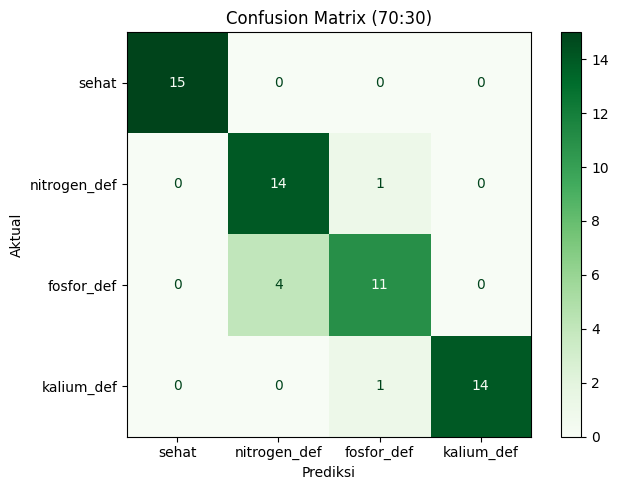

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=CONFIG["CLASSES"],
    cmap='Greens',
    ax=ax
)
ax.set_title("Confusion Matrix (70:30)")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.tight_layout()

save_path = os.path.join(CONFIG["OUTPUT_DIR"], "confusion_matrix_7030.png")
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

In [37]:
file_names_test = [file_names[i] for i in idx_test]
proba = best_model.predict_proba(F_test)
confidence = proba.max(axis=1)

pred_df = pd.DataFrame({
    "file_name"  : file_names_test,
    "aktual"     : [CONFIG["CLASSES"][i] for i in y_test],
    "prediksi"   : [CONFIG["CLASSES"][i] for i in y_pred],
    "confidence" : [f"{c*100:.1f}%" for c in confidence],
})
pred_df["status"] = pred_df.apply(
    lambda r: "benar" if r["aktual"] == r["prediksi"] else "salah", axis=1
)

print(f"Total benar : {(pred_df['status'] == 'benar').sum()} / {len(pred_df)}")
print(f"Total salah : {(pred_df['status'] == 'salah').sum()} / {len(pred_df)}")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

pred_df

Total benar : 54 / 60
Total salah : 6 / 60


,file_name,aktual,prediksi,confidence,status
0,sehat_IMG_20260509_101542_P6_D10.jpg,sehat,sehat,99.9%,benar
1,sehat_IMG_20260509_101700_P6_D12.jpg,sehat,sehat,100.0%,benar
2,kalium_def_(68)_JPG.rf.Qq8as7JlOyBK5yH9tf6W.JPG,kalium_def,kalium_def,100.0%,benar
3,kalium_def_(48)_JPG.rf.Uj7GW4OWpk2oqtrK52gT.JPG,kalium_def,kalium_def,99.2%,benar
4,kalium_def_IMG_20260517_102204_P11_D5.jpg,kalium_def,kalium_def,99.7%,benar
5,fosfor_def_(129)_jpg.rf.mXzU8sNMWFue39R7CzAP.jpg,fosfor_def,fosfor_def,66.8%,benar
6,sehat_IMG_20260509_100209_P5_D6.jpg,sehat,sehat,97.9%,benar
7,kalium_def_IMG_20260517_102146_P11_D4.jpg,kalium_def,kalium_def,99.2%,benar
8,kalium_def_IMG_20260517_110149_P12_D4.jpg,kalium_def,kalium_def,99.8%,benar
9,nitrogen_def_(34)_jpg.rf.BHgFMGpjy4GMbvvPEp9D.jpg,nitrogen_def,nitrogen_def,85.5%,benar


In [38]:
import shutil

OUTPUT_TEST_DIR = os.path.join(CONFIG["OUTPUT_DIR"], "test_images")
os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

for i in idx_test:
    kelas = CONFIG["CLASSES"][y[i]]
    src   = os.path.join(CONFIG["DATASET_DIR"], kelas, file_names[i])
    dst   = os.path.join(OUTPUT_TEST_DIR, kelas, file_names[i])
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

print(f"{len(idx_test)} gambar disimpan → {OUTPUT_TEST_DIR}")
for kelas in CONFIG["CLASSES"]:
    n = sum(CONFIG["CLASSES"][y[i]] == kelas for i in idx_test)
    print(f"  {kelas}: {n} gambar")

60 gambar disimpan → ../clf/output_7030/test_images
  sehat: 15 gambar
  nitrogen_def: 15 gambar
  fosfor_def: 15 gambar
  kalium_def: 15 gambar


## Simpan Model

In [39]:
pipeline_path = os.path.join(CONFIG["OUTPUT_DIR"], "pipeline_cocoa.joblib")
joblib.dump(best_model, pipeline_path)
print(f"Pipeline disimpan: {pipeline_path}")

Pipeline disimpan: ../clf/output_7030/pipeline_cocoa.joblib


## Export SVM & Scaler ke JSON

In [40]:
scaler = best_model.named_steps['scaler']
svm    = best_model.named_steps['classifier']

OUT = CONFIG["OUTPUT_DIR"]

scaler_path = os.path.join(OUT, "scaler_params.json")
with open(scaler_path, "w") as f:
    json.dump({"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}, f)
print(f"scaler_params.json  ({os.path.getsize(scaler_path)/1024:.0f} KB)")

kernel         = svm.estimator.kernel
coef_json      = [est.coef_.tolist()      for est in svm.estimators_]
intercept_json = [est.intercept_.tolist() for est in svm.estimators_]

probA_json = [est.probA_.tolist() for est in svm.estimators_]
probB_json = [est.probB_.tolist() for est in svm.estimators_]

svm_path = os.path.join(OUT, "svm_weights.json")
with open(svm_path, "w") as f:
    json.dump({
        "kernel"   : kernel,
        "C"        : svm.estimator.C,
        "classes"  : svm.classes_.tolist(),
        "labels"   : CONFIG["CLASSES"],
        "coef"     : coef_json,
        "intercept": intercept_json,
        "probA"    : probA_json,
        "probB"    : probB_json,
    }, f)
print(f"svm_weights.json    ({os.path.getsize(svm_path)/1024:.0f} KB)")
print(f"  probA: {[round(v[0],6) for v in probA_json]}")
print(f"  probB: {[round(v[0],6) for v in probB_json]}")


scaler_params.json  (184 KB)
svm_weights.json    (418 KB)
  probA: [-5.236573, -6.042147, -6.847369, -5.970111]
  probB: [-0.120262, 0.009534, 0.291419, 0.615582]


In [ ]:
def extract_features_tflite(tflite_path, pre_fn, X_uint8):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    features = []
    for i in range(len(X_uint8)):
        img_pre = pre_fn(X_uint8[i].astype(np.float32))
        inp     = np.expand_dims(img_pre, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        features.append(out[0])
    return np.array(features)


TFLITE_CNN_CFG = [
    ("resnet50",    pre_resnet,    X224_test),
    ("vgg16",       pre_vgg,       X224_test),
    ("inceptionv3", pre_inception, X299_test),
]

QUANTIZATION_METHODS = ["float16", "dynamic_int8", "full_int8"]

print(f"{'Metode':<16} {'Akurasi':>9} {'Presisi':>9} {'Recall':>9} {'F1-Score':>9}")
print("-" * 57)

results_tflite = {}

for method in QUANTIZATION_METHODS:
    F_test_tflite_list = []
    for cnn_name, pre_fn, X_test_cnn in TFLITE_CNN_CFG:
        tflite_path = os.path.join("../clf/export_tflite", f"{cnn_name}_{method}.tflite")
        feats = extract_features_tflite(tflite_path, pre_fn, X_test_cnn)
        F_test_tflite_list.append(feats)

    F_test_tflite = np.concatenate(F_test_tflite_list, axis=1)

    y_pred_tflite = best_model.predict(F_test_tflite)

    acc  = accuracy_score(y_test,  y_pred_tflite)
    prec = precision_score(y_test, y_pred_tflite, average='weighted', zero_division=0)
    rec  = recall_score(y_test,    y_pred_tflite, average='weighted', zero_division=0)
    f1   = f1_score(y_test,        y_pred_tflite, average='weighted', zero_division=0)

    results_tflite[method] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                                  y_pred=y_pred_tflite)

    print(f"{method:<16} {acc:>9.4f} {prec:>9.4f} {rec:>9.4f} {f1:>9.4f}")